# POPCON — SPARC PRD (cfspopcon reproduction)

Batched popcon scan of the fusdb transcription of cfspopcon's SPARC PRD case.
Every grid point holds the inputs exactly, solves the free core (`P_aux`), and is
individually certified. The datasheet performance entries (`P_fus`, `Q`, `W_th`, …)
are released first — a scan derives them, so supplying them would over-determine
every off-nominal point.

Two figures, built to be **structurally similar** to cfspopcon's reference plots in
`tests/cfspopcon_SPARC/output/` (`plot_popcon.png`, `plot_remapped.png`):

1. **`<T_e>` vs `<n_e>`** — filled colour is `Q`, with iso-contours for `Q`,
   `P_SOL/P_LH`, `P_aux,launched`, and `P_fus`.
2. **`P_RF` (launched auxiliary power) vs `<n_e>`** — the *same scan remapped* so the
   x-axis becomes `P_aux_launched`; filled colour `Q`, iso-contours `Q`,
   `P_SOL/P_LH`, `P_aux`, `P_fus`.

The reactor fixture supplies the profile, composition, confinement, heating, and
radiation choices used by the scan; the example only loads it and calls
`Reactor.popcon`. `Q` is saturated at 50 for display. `P_SOL/P_LH` is
formed as `(P_loss − P_rad)/P_LH` (cfspopcon's `P_in` ≙ fusdb `P_loss`; `P_sep`
has no standalone provider). The reference's `t_flattop` contour is omitted — it
needs the full central-solenoid flux-consumption chain, not tractable to reconcile
per point across the whole scan.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while root != root.parent and not (root / "src" / "fusdb").is_dir():
    root = root.parent
src_path = str(root / "src")
if not sys.path or sys.path[0] != src_path:
    sys.path.insert(0, src_path)

from fusdb.reactor import Reactor
from fusdb.plotting import plot_field_map, popcon_field_map

reactor = Reactor.from_yaml(root / "tests" / "cfspopcon_SPARC" / "reactor.yaml")
reactor.name

'SPARC PRD (cfspopcon)'

In [2]:
import time

t0 = time.perf_counter()
result = reactor.popcon(
    x={"variable": "average_electron_temp", "start": 8.0, "stop": 18.0, "num": 5},
    y={"variable": "average_electron_density", "start": 20.0e19, "stop": 38.0e19, "num": 5},
    outputs=(
        "P_fus",
        "P_aux",
        "P_aux_launched",  # launched RF power -> plot 2 x-axis
        "Q_sci",
        "P_loss",          # cfspopcon P_in
        "P_rad",           # total radiation; provider aggregates current components
        "P_LH",
        "f_GW",
    ),
)
print(f"{result['termination']} in {time.perf_counter() - t0:.0f}s")
payload = result["popcon"]

popcon auto-regime: 25/25 points solved (h_mode=20, l_mode=5, ohmic_mode=0) in 16s


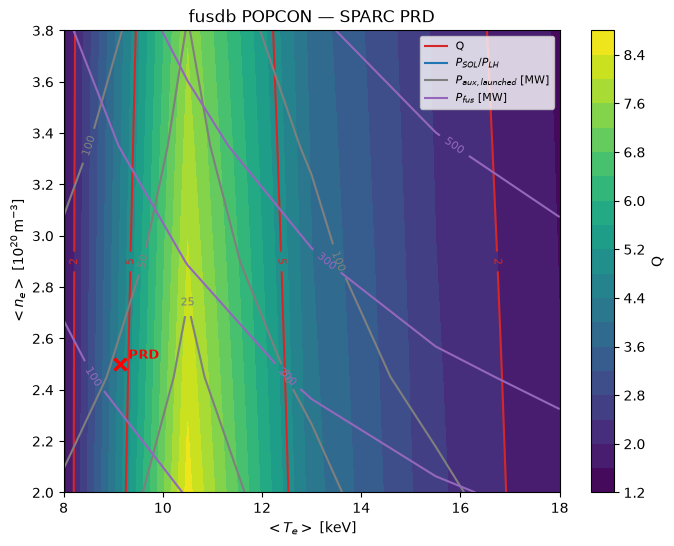

In [3]:
# --- Derive the plot fields from the scan (shared by both figures) ---
f = payload["fields"]
Te = np.asarray(payload["x"]["values"], float)           # <T_e> [keV]
ne20 = np.asarray(payload["y"]["values"], float) / 1e20  # <n_e> [1e20 m^-3]
success = np.asarray(payload["success"], bool)

# With peaked profiles the plasma reaches ignition (P_aux -> 0), where Q -> inf;
# saturate Q at 50 for display, as cfspopcon's reference plot does.
Q = np.minimum(f["Q_sci"], 50.0)
P_fus_MW = f["P_fus"] / 1e6
P_aux_launched_MW = f["P_aux_launched"] / 1e6
# cfspopcon: P_SOL = P_in - P_rad, and cfspopcon's P_in is fusdb's P_loss.
P_SOL_over_P_LH = (f["P_loss"] - f["P_rad"]) / f["P_LH"]

# Semantic colours matching the cfspopcon reference plots.
COLORS = {
    "Q": "tab:red",
    "$P_{SOL}/P_{LH}$": "tab:blue",
    "$P_{aux,launched}$ [MW]": "tab:gray",
    "$P_{aux}$ [MW]": "tab:gray",
    "$P_{fus}$ [MW]": "tab:purple",
}
PRD = (9.13793, 2.5)  # (<T_e> [keV], <n_e> [1e20 m^-3])

# --- Plot 1: <T_e> vs <n_e> ---
display = {
    "x": {"name": "$<T_e>$ [keV]", "values": Te},
    "y": {"name": "$<n_e>$ [$10^{20}\\,\\mathrm{m^{-3}}$]", "values": ne20},
    "success": success,
    "fields": {
        "Q": Q,
        "$P_{SOL}/P_{LH}$": P_SOL_over_P_LH,
        "$P_{aux,launched}$ [MW]": P_aux_launched_MW,
        "$P_{fus}$ [MW]": P_fus_MW,
    },
}
field_map = popcon_field_map(display, title="fusdb POPCON — SPARC PRD")
ax = plot_field_map(
    field_map,
    fill="Q",
    contours=("Q", "$P_{SOL}/P_{LH}$", "$P_{aux,launched}$ [MW]", "$P_{fus}$ [MW]"),
    levels={
        "Q": [1, 2, 5, 10, 20, 50],
        "$P_{SOL}/P_{LH}$": [1.0],
        "$P_{aux,launched}$ [MW]": [1, 5, 10, 25, 50, 100],
        "$P_{fus}$ [MW]": [50, 100, 200, 300, 500],
    },
    colors=COLORS,
)
ax.plot(*PRD, "x", color="red", ms=9, mew=2.5, zorder=5)
ax.annotate("PRD", PRD, textcoords="offset points", xytext=(6, 4),
            color="red", fontsize=9, fontweight="bold")
ax.figure.set_size_inches(8, 6)
plt.show()

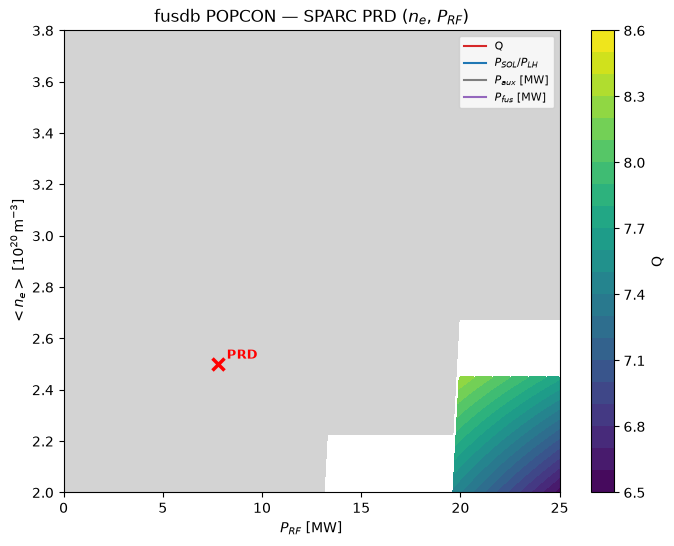

In [4]:
# --- Plot 2: remap the scan onto a P_RF (launched auxiliary power) x-axis ---
def remap_x(source_x, fields, new_x):
    """Interpolate every field from the <T_e> samples onto ``new_x`` using
    ``source_x`` (here P_aux_launched, MW) as the new coordinate, row by row at
    fixed <n_e>. Points outside a row's achievable P_RF range become NaN."""
    ny = source_x.shape[0]
    out = {name: np.full((ny, new_x.size), np.nan) for name in fields}
    for iy in range(ny):
        row_x = source_x[iy]
        good = np.isfinite(row_x)
        if good.sum() < 2:
            continue
        xs = row_x[good]
        order = np.argsort(xs)
        xs = xs[order]
        keep = np.concatenate(([True], np.diff(xs) > 0))  # strictly increasing
        xs = xs[keep]
        if xs.size < 2:
            continue
        in_range = (new_x >= xs[0]) & (new_x <= xs[-1])
        for name, arr in fields.items():
            ys = arr[iy][good][order][keep]
            row = np.full(new_x.size, np.nan)
            row[in_range] = np.interp(new_x, xs, ys)[in_range]
            out[name][iy] = row
    return out

P_RF = np.linspace(0.0, 25.0, 80)  # launched RF power [MW]
remapped = remap_x(
    P_aux_launched_MW,
    {
        "Q": Q,
        "$P_{SOL}/P_{LH}$": P_SOL_over_P_LH,
        "$P_{aux}$ [MW]": P_aux_launched_MW,
        "$P_{fus}$ [MW]": P_fus_MW,
        "success": success.astype(float),
    },
    P_RF,
)
remapped_success = remapped.pop("success") > 0.5

display_remapped = {
    "x": {"name": "$P_{RF}$ [MW]", "values": P_RF},
    "y": {"name": "$<n_e>$ [$10^{20}\\,\\mathrm{m^{-3}}$]", "values": ne20},
    "success": remapped_success,
    "fields": remapped,
}
field_map = popcon_field_map(display_remapped, title="fusdb POPCON — SPARC PRD ($n_e$, $P_{RF}$)")
ax = plot_field_map(
    field_map,
    fill="Q",
    contours=("Q", "$P_{SOL}/P_{LH}$", "$P_{aux}$ [MW]", "$P_{fus}$ [MW]"),
    levels={
        "Q": [1, 2, 5, 10, 20, 50],
        "$P_{SOL}/P_{LH}$": [1.0],
        "$P_{aux}$ [MW]": [1, 5, 10, 25],
        "$P_{fus}$ [MW]": [50, 100, 200, 300, 500],
    },
    colors=COLORS,
)
ax.plot(7.8, 2.5, "x", color="red", ms=9, mew=2.5, zorder=5)
ax.annotate("PRD", (7.8, 2.5), textcoords="offset points", xytext=(6, 4),
            color="red", fontsize=9, fontweight="bold")
ax.figure.set_size_inches(8, 6)
plt.show()